## XGBoost Model

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, balanced_accuracy_score, ConfusionMatrixDisplay,
    recall_score
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load preprocessed data from 6_Feature_Engineering_and_XGBoost
df_train = pd.read_csv('../3_Data_Preprocessing/preprocessing_data/train_engineered.csv')
df_test = pd.read_csv('../3_Data_Preprocessing/preprocessing_data/test_engineered.csv')

# Load feature lists and label encoder metadata
with open('../3_Data_Preprocessing/preprocessing_data/feature_engineering_metadata.json') as f:
    metadata = json.load(f)

all_features = metadata['all_features']
categorical_features = metadata['categorical_features']
optimal_features = metadata['optimal_features']

# Reconstruct label encoders from saved classes
label_encoders = {}
for col, classes in metadata['label_encoder_classes'].items():
    le = LabelEncoder()
    le.classes_ = np.array(classes)
    label_encoders[col] = le

# Prepare X, y
X_train = df_train[all_features].copy()
y_train = df_train['binary_target'].copy()
X_test = df_test[all_features].copy()
y_test = df_test['binary_target'].copy()

# Optimal feature subsets from dimensionality reduction
X_train_final = X_train[optimal_features].copy()
X_test_final = X_test[optimal_features].copy()

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_train_final (optimal): {X_train_final.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')
print(f'y_train distribution: {Counter(y_train)}')
print(f'y_test distribution:  {Counter(y_test)}')

X_train: (1490293, 26), y_train: (1490293,)
X_train_final (optimal): (1490293, 20)
X_test:  (308479, 26), y_test:  (308479,)
y_train distribution: Counter({0: 1128200, 1: 362093})
y_test distribution:  Counter({0: 236581, 1: 71898})


---
## Model Training with Stratified K-Fold Cross-Validation

Stratified 5-fold CV with undersampling within each fold

In [3]:
# Stratified 5-Fold CV with undersampling per fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
fold_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_final, y_train), 1):
    print(f'\n--- Fold {fold}/5 ---')
    
    X_fold_train = X_train_final.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val = X_train_final.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    # Undersample within this fold (no synthetic data)
    rus = RandomUnderSampler(random_state=42 + fold)
    X_fold_us, y_fold_us = rus.fit_resample(X_fold_train, y_fold_train)
    print(f'  Fold train (undersampled): {Counter(y_fold_us)}')
    
    # Train XGBoost
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        max_depth=6,
        learning_rate=0.1,
        n_estimators=500,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        early_stopping_rounds=30
    )
    model.fit(
        X_fold_us, y_fold_us,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )
    
    # Evaluate on validation fold
    y_val_pred = model.predict(X_fold_val)
    f1 = f1_score(y_fold_val, y_val_pred, average='macro')
    bal_acc = balanced_accuracy_score(y_fold_val, y_val_pred)
    fold_recall = recall_score(y_fold_val, y_val_pred, pos_label=1)
    
    cv_results.append({'fold': fold, 'macro_f1': f1, 'balanced_acc': bal_acc, 'at_risk_recall': fold_recall})
    fold_models.append(model)
    print(f'  Macro F1: {f1:.4f}, Balanced Acc: {bal_acc:.4f}, At-Risk Recall: {fold_recall:.4f}')

cv_df = pd.DataFrame(cv_results)
print(f'\n=== Cross-Validation Summary ===')
print(f'Mean Macro F1:      {cv_df["macro_f1"].mean():.4f} (+/- {cv_df["macro_f1"].std():.4f})')
print(f'Mean Balanced Acc:  {cv_df["balanced_acc"].mean():.4f} (+/- {cv_df["balanced_acc"].std():.4f})')
print(f'Mean At-Risk Recall: {cv_df["at_risk_recall"].mean():.4f} (+/- {cv_df["at_risk_recall"].std():.4f})')


--- Fold 1/5 ---
  Fold train (undersampled): Counter({0: 289674, 1: 289674})
  Macro F1: 0.6935, Balanced Acc: 0.7500, At-Risk Recall: 0.7879

--- Fold 2/5 ---
  Fold train (undersampled): Counter({0: 289674, 1: 289674})
  Macro F1: 0.6939, Balanced Acc: 0.7497, At-Risk Recall: 0.7855

--- Fold 3/5 ---
  Fold train (undersampled): Counter({0: 289674, 1: 289674})
  Macro F1: 0.6937, Balanced Acc: 0.7487, At-Risk Recall: 0.7821

--- Fold 4/5 ---
  Fold train (undersampled): Counter({0: 289675, 1: 289675})
  Macro F1: 0.6934, Balanced Acc: 0.7490, At-Risk Recall: 0.7843

--- Fold 5/5 ---
  Fold train (undersampled): Counter({0: 289675, 1: 289675})
  Macro F1: 0.6930, Balanced Acc: 0.7485, At-Risk Recall: 0.7832

=== Cross-Validation Summary ===
Mean Macro F1:      0.6935 (+/- 0.0003)
Mean Balanced Acc:  0.7492 (+/- 0.0007)
Mean At-Risk Recall: 0.7846 (+/- 0.0022)


---
## Final Model Training & Holdout Evaluation

In [4]:
# Train final model on full undersampled training data, evaluate on 2024 holdout
rus_final = RandomUnderSampler(random_state=42)
X_train_us_final, y_train_us_final = rus_final.fit_resample(X_train_final, y_train)
print(f'Final training set (undersampled): {Counter(y_train_us_final)}')

# XGBoost final
xgb_final = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=30
)

xgb_final.fit(
    X_train_us_final, y_train_us_final,
    eval_set=[(X_test_final, y_test)],
    verbose=False
)

y_pred_xgb = xgb_final.predict(X_test_final)
y_proba_xgb = xgb_final.predict_proba(X_test_final)[:, 1]

print('\n=== XGBoost Binary — 2024 Holdout Results ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Stable', 'At-Risk']))
print(f'Macro F1: {f1_score(y_test, y_pred_xgb, average="macro"):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'At-Risk Recall: {recall_score(y_test, y_pred_xgb, pos_label=1):.4f}')

Final training set (undersampled): Counter({0: 362093, 1: 362093})

=== XGBoost Binary — 2024 Holdout Results ===
              precision    recall  f1-score   support

      Stable       0.91      0.72      0.80    236581
     At-Risk       0.46      0.78      0.57     71898

    accuracy                           0.73    308479
   macro avg       0.68      0.75      0.69    308479
weighted avg       0.81      0.73      0.75    308479

Macro F1: 0.6892
Balanced Accuracy: 0.7471
At-Risk Recall: 0.7758


---
## Recall-Focused Threshold Tuning

Default threshold is 0.5. Lowering it catches more at-risk individuals (higher recall) at the cost of more false positives.

Best F1 threshold: 0.565 (F1=0.5791)
80% recall threshold: 0.472


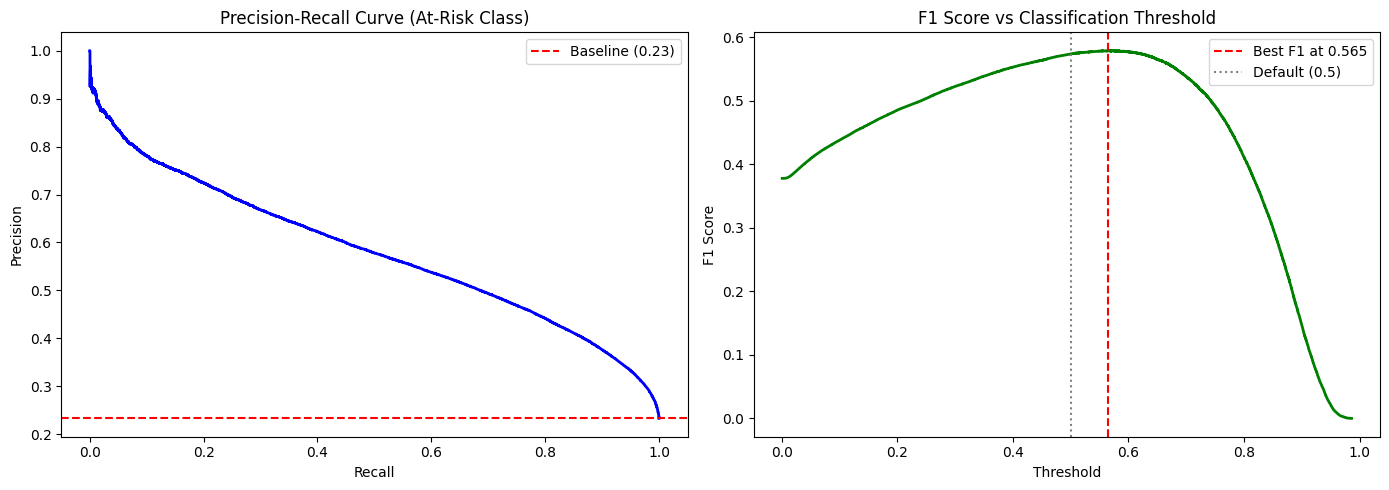

In [5]:
# Precision-Recall curve and threshold analysis
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba_xgb)

# Find threshold that maximizes F1
f1_scores = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-8)
best_threshold_f1 = thresholds[np.argmax(f1_scores)]

# Find threshold for 80% recall
recall_80_idx = np.argmin(np.abs(recall_vals[:-1] - 0.80))
threshold_recall_80 = thresholds[recall_80_idx]

print(f'Best F1 threshold: {best_threshold_f1:.3f} (F1={np.max(f1_scores):.4f})')
print(f'80% recall threshold: {threshold_recall_80:.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
ax1.plot(recall_vals, precision_vals, 'b-', linewidth=2)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve (At-Risk Class)')
ax1.axhline(y=y_test.mean(), color='r', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
ax1.legend()

# F1 vs Threshold
ax2.plot(thresholds, f1_scores, 'g-', linewidth=2)
ax2.axvline(x=best_threshold_f1, color='r', linestyle='--', label=f'Best F1 at {best_threshold_f1:.3f}')
ax2.axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('F1 Score')
ax2.set_title('F1 Score vs Classification Threshold')
ax2.legend()

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/precision_recall_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Apply optimized threshold
y_pred_optimized = (y_proba_xgb >= best_threshold_f1).astype(int)

print(f'=== XGBoost with Optimized Threshold ({best_threshold_f1:.3f}) ===')
print(classification_report(y_test, y_pred_optimized, target_names=['Stable', 'At-Risk']))
print(f'Macro F1: {f1_score(y_test, y_pred_optimized, average="macro"):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_optimized):.4f}')

=== XGBoost with Optimized Threshold (0.565) ===
              precision    recall  f1-score   support

      Stable       0.90      0.78      0.83    236581
     At-Risk       0.49      0.71      0.58     71898

    accuracy                           0.76    308479
   macro avg       0.69      0.74      0.71    308479
weighted avg       0.80      0.76      0.77    308479

Macro F1: 0.7055
Balanced Accuracy: 0.7421


In [7]:
# Also try the high-recall threshold for the social services use case
y_pred_high_recall = (y_proba_xgb >= threshold_recall_80).astype(int)

print(f'=== XGBoost with High-Recall Threshold ({threshold_recall_80:.3f}) ===')
print(classification_report(y_test, y_pred_high_recall, target_names=['Stable', 'At-Risk']))
print(f'Macro F1: {f1_score(y_test, y_pred_high_recall, average="macro"):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_high_recall):.4f}')

=== XGBoost with High-Recall Threshold (0.472) ===
              precision    recall  f1-score   support

      Stable       0.92      0.69      0.79    236581
     At-Risk       0.44      0.80      0.57     71898

    accuracy                           0.72    308479
   macro avg       0.68      0.75      0.68    308479
weighted avg       0.81      0.72      0.74    308479

Macro F1: 0.6796
Balanced Accuracy: 0.7463


---
## Confusion Matrices & Final Comparison

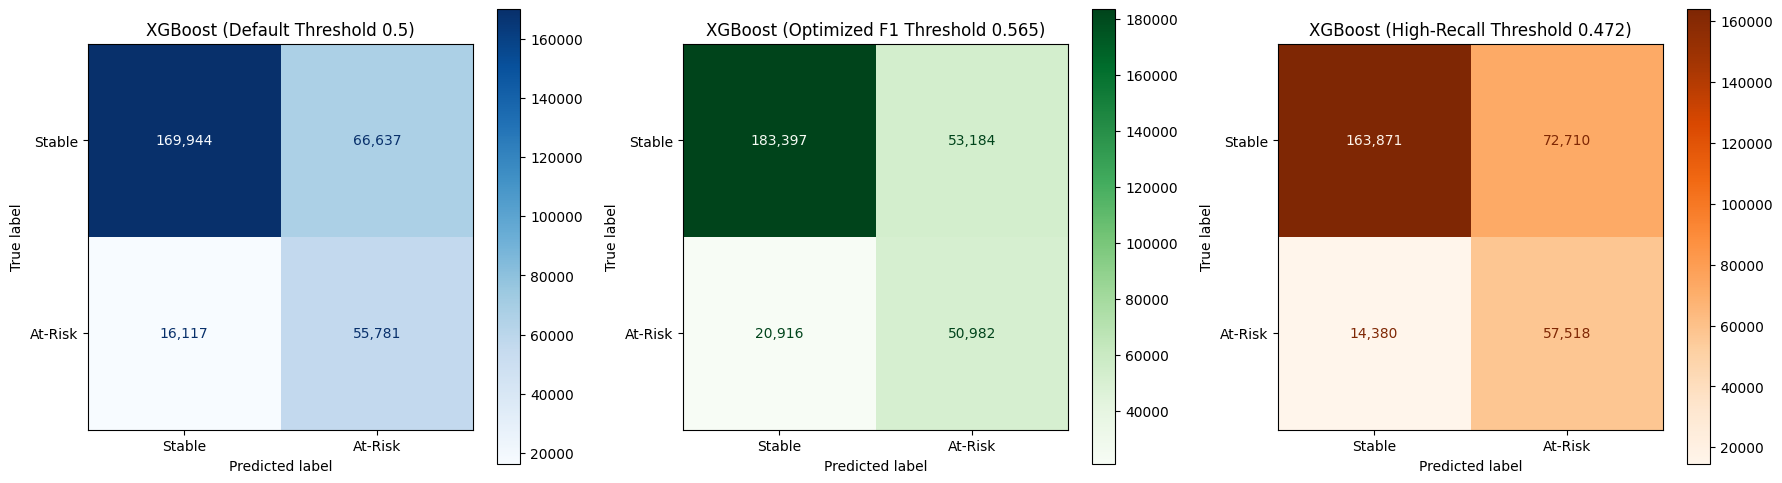

In [8]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Default threshold
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, display_labels=['Stable', 'At-Risk'],
    ax=axes[0], cmap='Blues', values_format=','
)
axes[0].set_title('XGBoost (Default Threshold 0.5)')

# Optimized F1 threshold
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_optimized, display_labels=['Stable', 'At-Risk'],
    ax=axes[1], cmap='Greens', values_format=','
)
axes[1].set_title(f'XGBoost (Optimized F1 Threshold {best_threshold_f1:.3f})')

# High recall threshold
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_high_recall, display_labels=['Stable', 'At-Risk'],
    ax=axes[2], cmap='Oranges', values_format=','
)
axes[2].set_title(f'XGBoost (High-Recall Threshold {threshold_recall_80:.3f})')

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/confusion_matrices_engineered.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Compare baseline vs feature-engineered model
print('=' * 70)
print('COMPARISON: Baseline vs. Feature-Engineered Model')
print('=' * 70)
print(f'{"Metric":<25} {"Baseline (Logistic Reg)":<25} {"XGBoost (Engineered)":<25}')
print('-' * 70)

# Baseline results from notebook 3 (logistic regression binary)
baseline_f1 = 0.57
baseline_acc = 0.70

new_f1 = f1_score(y_test, y_pred_xgb, average='macro')
new_acc = (y_pred_xgb == y_test).mean()
new_bal_acc = balanced_accuracy_score(y_test, y_pred_xgb)

print(f'{"Macro F1":<25} {baseline_f1:<25.4f} {new_f1:<25.4f}')
print(f'{"Accuracy":<25} {baseline_acc:<25.4f} {new_acc:<25.4f}')
print(f'{"At-Risk Recall":<25} {"-":<25} {recall_score(y_test, y_pred_xgb, pos_label=1):<25.4f}')
print(f'{"Num Features":<25} {25:<25} {len(optimal_features):<25}')
print('-' * 70)

# CV results
print(f'\nCross-Validation (5-fold): Macro F1 = {cv_df["macro_f1"].mean():.4f} +/- {cv_df["macro_f1"].std():.4f}')
print(f'\nKey improvements over baseline:')
print(f'  - Race: Label-encoded → One-hot encoded (no hierarchical bias)')
print(f'  - Insurance: 3 features → 1 binary (removed quasi-leakage from PRIVCOV)')
print(f'  - Disability: Binary → 0-6 comorbidity score (richer signal)')
print(f'  - Education: Raw ordinal → 5-level tier (domain-informed)')
print(f'  - Validation: Single split → Stratified 5-fold CV')
print(f'  - Model: Logistic Regression → XGBoost with threshold tuning')

COMPARISON: Baseline vs. Feature-Engineered Model
Metric                    Baseline (Logistic Reg)   XGBoost (Engineered)     
----------------------------------------------------------------------
Macro F1                  0.5700                    0.6892                   
Accuracy                  0.7000                    0.7317                   
At-Risk Recall            -                         0.7758                   
Num Features              25                        20                       
----------------------------------------------------------------------

Cross-Validation (5-fold): Macro F1 = 0.6935 +/- 0.0003

Key improvements over baseline:
  - Race: Label-encoded → One-hot encoded (no hierarchical bias)
  - Insurance: 3 features → 1 binary (removed quasi-leakage from PRIVCOV)
  - Disability: Binary → 0-6 comorbidity score (richer signal)
  - Education: Raw ordinal → 5-level tier (domain-informed)
  - Validation: Single split → Stratified 5-fold CV
  - Model: Log

---
## Multi-Class XGBoost (4-Class Poverty Severity)

- **0** = Stable (POVPIP > 150)
- **1** = Near Poverty (100 < POVPIP ≤ 150)
- **2** = Poverty (50 < POVPIP ≤ 100)
- **3** = Deep Poverty (POVPIP ≤ 50)

In [10]:
# Prepare 4-class target
y_train_multi = df_train['poverty_risk_score'].astype(int)
y_test_multi = df_test['poverty_risk_score'].astype(int)

print('Multi-class distribution (Train):')
print(y_train_multi.value_counts().sort_index())
print(f'\nMulti-class distribution (Test):')
print(y_test_multi.value_counts().sort_index())

class_names_multi = ['Stable (0)', 'Near Poverty (1)', 'Poverty (2)', 'Deep Poverty (3)']

Multi-class distribution (Train):
poverty_risk_score
0    1128200
1     200442
2      80529
3      81122
Name: count, dtype: int64

Multi-class distribution (Test):
poverty_risk_score
0    236581
1     39167
2     15836
3     16895
Name: count, dtype: int64


In [11]:
# Undersample for multi-class balance
rus_multi = RandomUnderSampler(random_state=42)
X_train_multi_us, y_train_multi_us = rus_multi.fit_resample(
    X_train[optimal_features], y_train_multi
)
print(f'Undersampled multi-class training set: {Counter(y_train_multi_us)}')

# Train 4-class XGBoost
xgb_multi = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

xgb_multi.fit(
    X_train_multi_us, y_train_multi_us,
    eval_set=[(X_test[optimal_features], y_test_multi)],
    verbose=50
)

print(f'\nBest iteration: {xgb_multi.best_iteration}')

Undersampled multi-class training set: Counter({0: 80529, 1: 80529, 2: 80529, 3: 80529})
[0]	validation_0-mlogloss:1.34282
[50]	validation_0-mlogloss:1.02354
[100]	validation_0-mlogloss:1.01337
[150]	validation_0-mlogloss:1.00901
[200]	validation_0-mlogloss:1.00638
[250]	validation_0-mlogloss:1.00508
[300]	validation_0-mlogloss:1.00405
[342]	validation_0-mlogloss:1.00400

Best iteration: 312


In [12]:
# Multi-class evaluation
y_pred_multi = xgb_multi.predict(X_test[optimal_features])

print('=== Multi-Class XGBoost (4 Poverty Levels) — 2024 Holdout ===')
print(classification_report(y_test_multi, y_pred_multi, target_names=class_names_multi))
print(f'Macro F1: {f1_score(y_test_multi, y_pred_multi, average="macro"):.4f}')
print(f'Weighted F1: {f1_score(y_test_multi, y_pred_multi, average="weighted"):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test_multi, y_pred_multi):.4f}')

=== Multi-Class XGBoost (4 Poverty Levels) — 2024 Holdout ===
                  precision    recall  f1-score   support

      Stable (0)       0.93      0.65      0.76    236581
Near Poverty (1)       0.23      0.40      0.29     39167
     Poverty (2)       0.15      0.34      0.21     15836
Deep Poverty (3)       0.25      0.54      0.34     16895

        accuracy                           0.60    308479
       macro avg       0.39      0.48      0.40    308479
    weighted avg       0.76      0.60      0.65    308479

Macro F1: 0.4006
Weighted F1: 0.6519
Balanced Accuracy: 0.4845


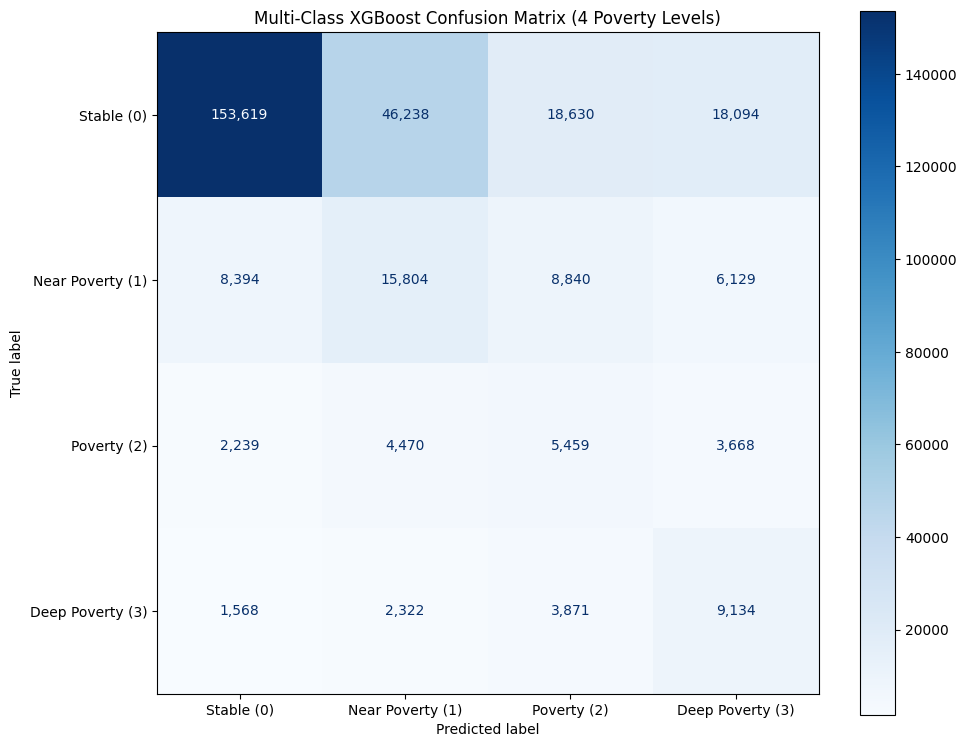

In [13]:
# Multi-class confusion matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_multi, y_pred_multi,
    display_labels=class_names_multi,
    ax=ax, cmap='Blues', values_format=','
)
ax.set_title('Multi-Class XGBoost Confusion Matrix (4 Poverty Levels)')
plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/xgboost_multiclass_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

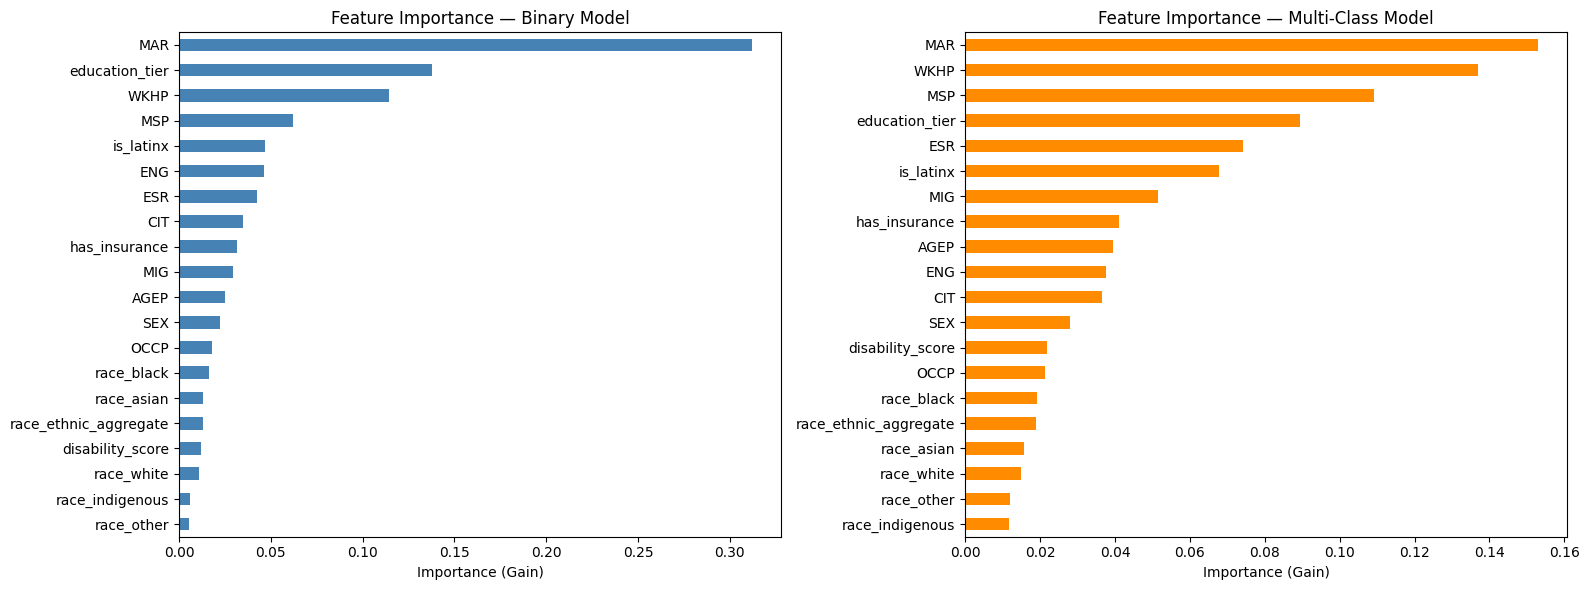

In [14]:
# Multi-class feature importance
importance_multi = pd.Series(
    xgb_multi.feature_importances_,
    index=optimal_features
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Binary importance (from earlier)
importance_binary = pd.Series(
    xgb_final.feature_importances_,
    index=optimal_features
).sort_values(ascending=False)

importance_binary.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — Binary Model')
axes[0].set_xlabel('Importance (Gain)')
axes[0].invert_yaxis()

importance_multi.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Feature Importance — Multi-Class Model')
axes[1].set_xlabel('Importance (Gain)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/feature_importance_binary_vs_multi.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Binary vs Multi-Class comparison
multi_f1 = f1_score(y_test_multi, y_pred_multi, average='macro')
multi_weighted_f1 = f1_score(y_test_multi, y_pred_multi, average='weighted')
multi_bal_acc = balanced_accuracy_score(y_test_multi, y_pred_multi)
binary_f1 = f1_score(y_test, y_pred_xgb, average='macro')
binary_bal_acc = balanced_accuracy_score(y_test, y_pred_xgb)

print('=' * 70)
print('COMPARISON: Binary vs Multi-Class XGBoost')
print('=' * 70)
print(f'{"Metric":<25} {"Binary (2-class)":<25} {"Multi-Class (4-class)":<25}')
print('-' * 70)
print(f'{"Macro F1":<25} {binary_f1:<25.4f} {multi_f1:<25.4f}')
print(f'{"Balanced Accuracy":<25} {binary_bal_acc:<25.4f} {multi_bal_acc:<25.4f}')
print(f'{"Classes":<25} {"Stable vs At-Risk":<25} {"0, 1, 2, 3":<25}')
print('-' * 70)
print(f'\nF1 drop from binary to multi-class: {binary_f1 - multi_f1:+.4f}')
print('\nNote: Lower multi-class F1 is expected — distinguishing between poverty')
print('severity levels (Near Poverty vs Poverty vs Deep Poverty) is harder')
print('than a simple Stable vs At-Risk split.')

COMPARISON: Binary vs Multi-Class XGBoost
Metric                    Binary (2-class)          Multi-Class (4-class)    
----------------------------------------------------------------------
Macro F1                  0.6892                    0.4006                   
Balanced Accuracy         0.7471                    0.4845                   
Classes                   Stable vs At-Risk         0, 1, 2, 3               
----------------------------------------------------------------------

F1 drop from binary to multi-class: +0.2886

Note: Lower multi-class F1 is expected — distinguishing between poverty
severity levels (Near Poverty vs Poverty vs Deep Poverty) is harder
than a simple Stable vs At-Risk split.


---
## Save Models & Artifacts

In [16]:
# Save final XGBoost model
xgb_final.save_model('../3_Data_Preprocessing/preprocessing_data/xgboost_engineered_binary.json')
print('Saved: xgboost_engineered_binary.json')

# Save feature list and metadata
import json

metadata = {
    'optimal_features': optimal_features,
    'n_features': len(optimal_features),
    'best_threshold_f1': float(best_threshold_f1),
    'threshold_recall_80': float(threshold_recall_80),
    'cv_macro_f1_mean': float(cv_df['macro_f1'].mean()),
    'cv_macro_f1_std': float(cv_df['macro_f1'].std()),
    'holdout_macro_f1': float(new_f1),
    'holdout_accuracy': float(new_acc),
    'holdout_balanced_acc': float(new_bal_acc),
    'feature_engineering': {
        'disability_score': 'Sum of DEAR, DEYE, DPHY, DREM, DDRS, DOUT (0-6)',
        'has_insurance': 'Binary: HICOV==1 (has any insurance)',
        'race_columns': 'One-hot from RACWHT, RACBLK, RACASN, RACAIAN+RACNH+RACPI, RACSOR',
        'is_latinx': 'Binary: HISP > 1',
        'race_ethnic_aggregate': 'Sum of race one-hot + is_latinx',
        'education_tier': 'SCHL mapped to 0-4 (No HS, HS, Some College, Bachelors, Advanced)'
    },
    'dropped_features': {
            'DIS': 'Replaced by disability_score (0-6)',
            'HICOV': 'Replaced by has_insurance (binary)',
            'PRIVCOV': 'Replaced by has_insurance (binary) — was 0.32 importance, possible quasi-leakage',
            'PUBCOV': 'Replaced by has_insurance (binary) — Medi-Cal requires poverty-level income',
            'RAC1P': 'Replaced by one-hot race columns — label encoding was methodologically wrong',
            'SCHL': 'Replaced by education_tier (0-4)',
            'LANP': 'Dropped — 57% null, high cardinality (200+ languages)',
            'POBP': 'Dropped — high cardinality (200+ places of birth)',
            'year': 'Dropped — no temporal drift detected in random vs temporal split analysis'
        }
}

with open('../3_Data_Preprocessing/preprocessing_data/model_metadata_engineered.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Saved: model_metadata_engineered.json')

print('\nAll artifacts saved.')

Saved: xgboost_engineered_binary.json
Saved: model_metadata_engineered.json

All artifacts saved.


---
## Geographic Segmentation

Train separate models for each CA region and compare against the statewide model. If regional models outperform the statewide model, it means geographic stratification captures local poverty dynamics that get masked in aggregate.

Regional At-Risk Rates (Train Data):
                     at_risk_rate  n_samples
CA_Region_label                             
Bay Area                     33.8      84881
Central Valley               28.0     432261
San Diego/Border             26.1      64592
Central Coast                22.5     315078
Inland Empire                22.1      55024
Los Angeles                  21.3     407736
Northern CA/Sierras          19.5     130721


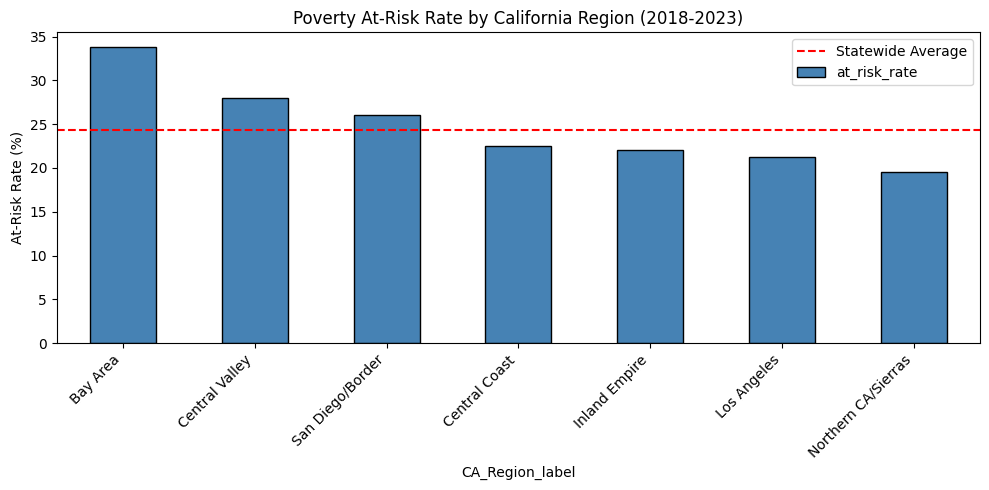

In [17]:
# Regional poverty rate overview
# Decode CA_Region back to string labels for groupby
region_le = label_encoders['CA_Region']
df_train['CA_Region_label'] = region_le.inverse_transform(df_train['CA_Region'])
df_test['CA_Region_label'] = region_le.inverse_transform(df_test['CA_Region'])

regions = df_train.groupby('CA_Region_label')['binary_target'].agg(['mean', 'count']).sort_values('mean', ascending=False)
regions.columns = ['at_risk_rate', 'n_samples']
regions['at_risk_rate'] = (regions['at_risk_rate'] * 100).round(1)

print('Regional At-Risk Rates (Train Data):')
print(regions.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
regions['at_risk_rate'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_ylabel('At-Risk Rate (%)')
ax.set_title('Poverty At-Risk Rate by California Region (2018-2023)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(y=df_train['binary_target'].mean() * 100, color='red', linestyle='--', label='Statewide Average')
ax.legend()
plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/regional_poverty_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Train separate XGBoost models per region
# Use features WITHOUT CA_Region and PUMA (since we're already segmenting by geography)
regional_features = [f for f in optimal_features if f not in ['CA_Region', 'PUMA']]
print(f'Regional model features ({len(regional_features)}): {regional_features}')

regional_results = []

for region in sorted(df_train['CA_Region_label'].unique()):
    # Split by region
    train_mask = df_train['CA_Region_label'] == region
    test_mask = df_test['CA_Region_label'] == region
    
    X_reg_train = df_train.loc[train_mask, regional_features]
    y_reg_train = df_train.loc[train_mask, 'binary_target']
    X_reg_test = df_test.loc[test_mask, regional_features]
    y_reg_test = df_test.loc[test_mask, 'binary_target']
    
    if len(X_reg_test) < 50 or y_reg_train.nunique() < 2:
        print(f'  {region}: Skipped (insufficient data)')
        continue
    
    # Undersample
    rus = RandomUnderSampler(random_state=42)
    X_reg_us, y_reg_us = rus.fit_resample(X_reg_train, y_reg_train)
    
    # Train regional model
    reg_model = xgb.XGBClassifier(
        objective='binary:logistic',
        max_depth=6, learning_rate=0.1,
        n_estimators=300, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', early_stopping_rounds=20
    )
    reg_model.fit(X_reg_us, y_reg_us, eval_set=[(X_reg_test, y_reg_test)], verbose=False)
    
    y_reg_pred = reg_model.predict(X_reg_test)
    reg_f1 = f1_score(y_reg_test, y_reg_pred, average='macro')
    reg_bal_acc = balanced_accuracy_score(y_reg_test, y_reg_pred)
    reg_recall = f1_score(y_reg_test, y_reg_pred, pos_label=1, average='binary')
    
    # Also get statewide model predictions for this region
    statewide_pred = xgb_final.predict(df_test.loc[test_mask, optimal_features])
    state_f1 = f1_score(y_reg_test, statewide_pred, average='macro')
    state_bal_acc = balanced_accuracy_score(y_reg_test, statewide_pred)
    
    regional_results.append({
        'Region': region,
        'n_train': len(X_reg_train),
        'n_test': len(X_reg_test),
        'at_risk_pct': y_reg_test.mean() * 100,
        'Regional_F1': reg_f1,
        'Regional_BalAcc': reg_bal_acc,
        'Statewide_F1': state_f1,
        'Statewide_BalAcc': state_bal_acc,
        'F1_Improvement': reg_f1 - state_f1
    })
    
    print(f'  {region:25s} | Regional F1: {reg_f1:.4f} | Statewide F1: {state_f1:.4f} | Delta: {reg_f1 - state_f1:+.4f}')

regional_df = pd.DataFrame(regional_results)

Regional model features (20): ['MSP', 'education_tier', 'WKHP', 'ESR', 'ENG', 'CIT', 'MIG', 'has_insurance', 'MAR', 'is_latinx', 'AGEP', 'SEX', 'race_black', 'OCCP', 'race_white', 'race_asian', 'race_indigenous', 'race_other', 'race_ethnic_aggregate', 'disability_score']
  Bay Area                  | Regional F1: 0.7078 | Statewide F1: 0.7029 | Delta: +0.0049
  Central Coast             | Regional F1: 0.6703 | Statewide F1: 0.6748 | Delta: -0.0045
  Central Valley            | Regional F1: 0.6924 | Statewide F1: 0.6837 | Delta: +0.0087
  Inland Empire             | Regional F1: 0.6674 | Statewide F1: 0.6780 | Delta: -0.0106
  Los Angeles               | Regional F1: 0.6842 | Statewide F1: 0.6921 | Delta: -0.0079
  Northern CA/Sierras       | Regional F1: 0.6868 | Statewide F1: 0.6985 | Delta: -0.0118
  San Diego/Border          | Regional F1: 0.6868 | Statewide F1: 0.6939 | Delta: -0.0071


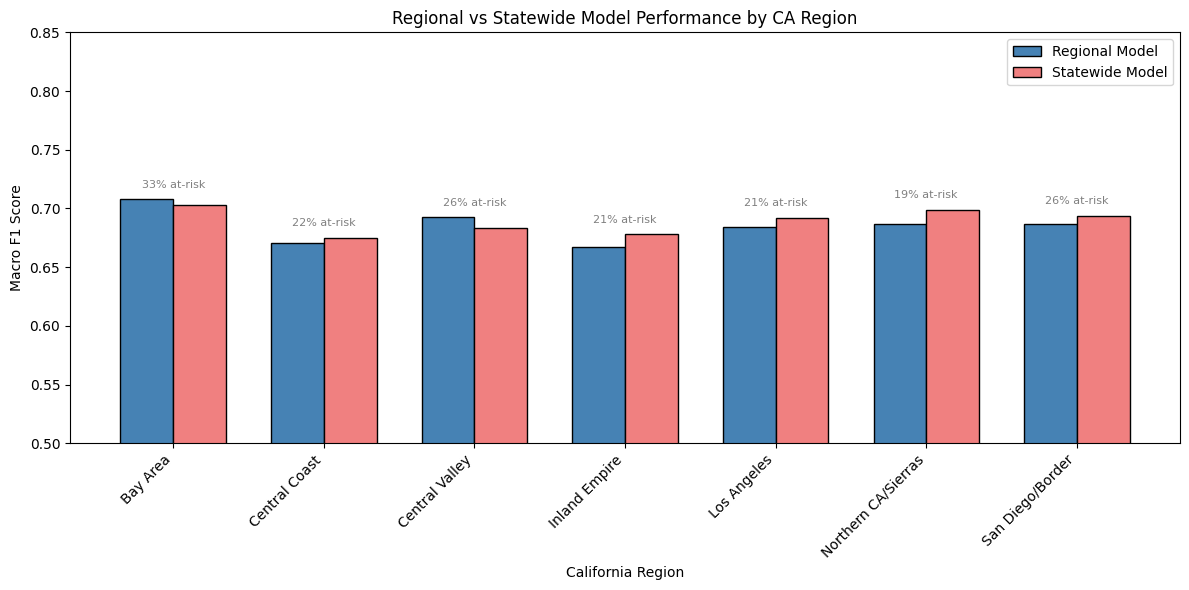


=== Geographic Segmentation Summary ===
             Region  at_risk_pct  Regional_F1  Statewide_F1  F1_Improvement
           Bay Area    32.928586     0.707759      0.702851        0.004908
      Central Coast    21.853486     0.670276      0.674803       -0.004527
     Central Valley    26.363212     0.692374      0.683671        0.008703
      Inland Empire    21.480851     0.667376      0.677979       -0.010603
        Los Angeles    20.507833     0.684210      0.692137       -0.007926
Northern CA/Sierras    18.740496     0.686761      0.698547       -0.011786
   San Diego/Border    25.601862     0.686754      0.693858       -0.007104

Regions where regional model outperforms statewide: 2/7
Average F1 improvement: -0.0040


In [19]:
# Visualize regional vs statewide performance
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(regional_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], regional_df['Regional_F1'], width,
               label='Regional Model', color='steelblue', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], regional_df['Statewide_F1'], width,
               label='Statewide Model', color='lightcoral', edgecolor='black')

ax.set_xlabel('California Region')
ax.set_ylabel('Macro F1 Score')
ax.set_title('Regional vs Statewide Model Performance by CA Region')
ax.set_xticks(x)
ax.set_xticklabels(regional_df['Region'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.5, 0.85)

# Add at-risk % labels on top
for i, row in regional_df.iterrows():
    ax.annotate(f'{row["at_risk_pct"]:.0f}% at-risk',
                xy=(i, max(row['Regional_F1'], row['Statewide_F1']) + 0.01),
                ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/regional_vs_statewide.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('\n=== Geographic Segmentation Summary ===')
print(regional_df[['Region', 'at_risk_pct', 'Regional_F1', 'Statewide_F1', 'F1_Improvement']].to_string(index=False))
avg_improvement = regional_df['F1_Improvement'].mean()
improved_count = (regional_df['F1_Improvement'] > 0).sum()
print(f'\nRegions where regional model outperforms statewide: {improved_count}/{len(regional_df)}')
print(f'Average F1 improvement: {avg_improvement:+.4f}')

---
## Segmented Factor Analysis

;Train models on specific feature subsets to understand which factor groups drive poverty prediction:


In [20]:
# Define factor-based feature subsets
# These use features from all_features (the full 26), not just the optimal set
factor_segments = {
    'Education & Earning Potential': ['education_tier', 'OCCP', 'WKHP', 'ENG'],
    'Demographics': ['AGEP', 'SEX', 'MAR', 'MSP', 'CIT', 'NATIVITY', 'MIG'],
    'Race & Ethnicity': ['race_white', 'race_black', 'race_asian', 'race_indigenous',
                         'race_other', 'is_latinx', 'race_ethnic_aggregate'],
    'Employment': ['ESR', 'WKHP', 'WKL', 'WRK', 'OCCP'],
    'Disability & Insurance': ['disability_score', 'has_insurance'],
    'Full Model (All Optimal)': optimal_features,
}

segment_results = []

for segment_name, segment_features in factor_segments.items():
    # Filter to features that exist in the training data
    valid_features = [f for f in segment_features if f in X_train.columns]
    
    X_seg_train = X_train[valid_features]
    X_seg_test = X_test[valid_features]
    
    # Undersample
    rus = RandomUnderSampler(random_state=42)
    X_seg_us, y_seg_us = rus.fit_resample(X_seg_train, y_train)
    
    # Train
    seg_model = xgb.XGBClassifier(
        objective='binary:logistic',
        max_depth=6, learning_rate=0.1,
        n_estimators=300, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', early_stopping_rounds=20
    )
    seg_model.fit(X_seg_us, y_seg_us, eval_set=[(X_seg_test, y_test)], verbose=False)
    
    y_seg_pred = seg_model.predict(X_seg_test)
    seg_f1 = f1_score(y_test, y_seg_pred, average='macro')
    seg_bal_acc = balanced_accuracy_score(y_test, y_seg_pred)
    
    # Get recall for at-risk class
    from sklearn.metrics import recall_score
    seg_recall = recall_score(y_test, y_seg_pred, pos_label=1)
    
    segment_results.append({
        'Segment': segment_name,
        'n_features': len(valid_features),
        'Features': ', '.join(valid_features),
        'Macro_F1': seg_f1,
        'Balanced_Acc': seg_bal_acc,
        'AtRisk_Recall': seg_recall
    })
    
    print(f'{segment_name:35s} | {len(valid_features):2d} features | F1: {seg_f1:.4f} | Bal Acc: {seg_bal_acc:.4f} | At-Risk Recall: {seg_recall:.4f}')

segment_df = pd.DataFrame(segment_results)

Education & Earning Potential       |  4 features | F1: 0.6273 | Bal Acc: 0.6999 | At-Risk Recall: 0.7727
Demographics                        |  7 features | F1: 0.5660 | Bal Acc: 0.6474 | At-Risk Recall: 0.7528
Race & Ethnicity                    |  7 features | F1: 0.5540 | Bal Acc: 0.5844 | At-Risk Recall: 0.5280
Employment                          |  5 features | F1: 0.5963 | Bal Acc: 0.6858 | At-Risk Recall: 0.8087
Disability & Insurance              |  2 features | F1: 0.5835 | Bal Acc: 0.5804 | At-Risk Recall: 0.3278
Full Model (All Optimal)            | 20 features | F1: 0.6882 | Bal Acc: 0.7463 | At-Risk Recall: 0.7756


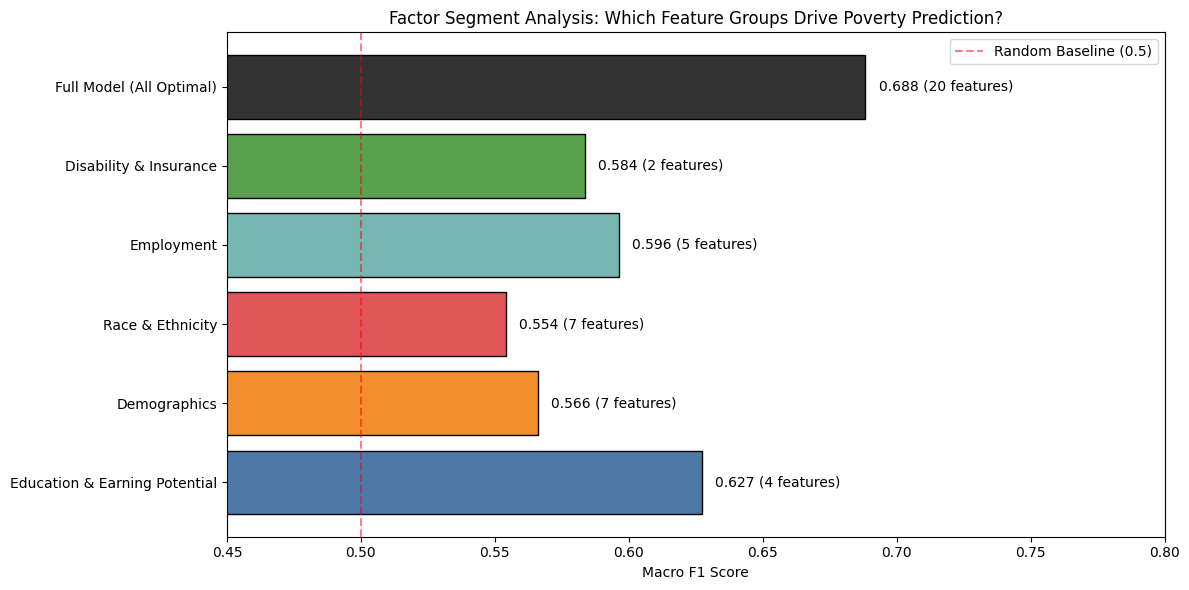


=== Key Insights ===
Strongest single factor group: Full Model (All Optimal) (F1=0.6882)
Weakest single factor group: Race & Ethnicity (F1=0.5540)

This tells us which dimensions of poverty are most predictable from ACS data alone.


In [21]:
# Visualize factor segment performance
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#333333']
bars = ax.barh(segment_df['Segment'], segment_df['Macro_F1'], color=colors, edgecolor='black')

# Add feature count labels
for i, (f1_val, n_feat) in enumerate(zip(segment_df['Macro_F1'], segment_df['n_features'])):
    ax.text(f1_val + 0.005, i, f'{f1_val:.3f} ({n_feat} features)', va='center', fontsize=10)

ax.set_xlabel('Macro F1 Score')
ax.set_title('Factor Segment Analysis: Which Feature Groups Drive Poverty Prediction?')
ax.set_xlim(0.45, 0.80)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random Baseline (0.5)')
ax.legend()

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/factor_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Key Insights ===')
best_seg = segment_df.loc[segment_df['Macro_F1'].idxmax()]
worst_seg = segment_df.loc[segment_df[segment_df['Segment'] != 'Full Model (12 features)']['Macro_F1'].idxmin()]
print(f'Strongest single factor group: {best_seg["Segment"]} (F1={best_seg["Macro_F1"]:.4f})')
print(f'Weakest single factor group: {worst_seg["Segment"]} (F1={worst_seg["Macro_F1"]:.4f})')
print(f'\nThis tells us which dimensions of poverty are most predictable from ACS data alone.')

---
## Final Comprehensive Comparison

Bringing together all model approaches across the entire project from the initial baseline logistic regression through feature engineering, geographic segmentation, and factor analysis.

In [22]:
# Comprehensive model comparison: Baseline vs Feature-Engineered XGBoost
all_models = pd.DataFrame([
    # Baseline from notebook 3
    {'Model': 'Logistic Regression (Baseline)', 'Notebook': '3', 'Type': 'Binary',
     'Features': 25, 'Macro_F1': 0.57, 'Accuracy': 0.70, 'Notes': 'Poverty class F1=0.00'},

    # This notebook — feature-engineered XGBoost
    {'Model': 'XGBoost Binary (Engineered)', 'Notebook': '6', 'Type': 'Binary',
     'Features': len(optimal_features), 'Macro_F1': round(f1_score(y_test, y_pred_xgb, average='macro'), 4),
     'Accuracy': round((y_pred_xgb == y_test).mean(), 4),
     'Notes': 'Insurance leakage removed, one-hot race'},
    {'Model': 'XGBoost Binary (Optimized Threshold)', 'Notebook': '6', 'Type': 'Binary',
     'Features': len(optimal_features), 'Macro_F1': round(f1_score(y_test, y_pred_optimized, average='macro'), 4),
     'Accuracy': round((y_pred_optimized == y_test).mean(), 4),
     'Notes': f'Threshold={best_threshold_f1:.3f}'},
    {'Model': 'XGBoost Binary (High-Recall)', 'Notebook': '6', 'Type': 'Binary',
     'Features': len(optimal_features), 'Macro_F1': round(f1_score(y_test, y_pred_high_recall, average='macro'), 4),
     'Accuracy': round((y_pred_high_recall == y_test).mean(), 4),
     'Notes': f'Threshold={threshold_recall_80:.3f}, At-Risk recall ≥ 0.80'},
])

print('=' * 100)
print('MODEL COMPARISON: Baseline vs Feature-Engineered XGBoost')
print('=' * 100)
print(all_models[['Model', 'Notebook', 'Features', 'Macro_F1', 'Accuracy', 'Notes']].to_string(index=False))
print('=' * 100)

MODEL COMPARISON: Baseline vs Feature-Engineered XGBoost
                               Model Notebook  Features  Macro_F1  Accuracy                                   Notes
      Logistic Regression (Baseline)        3        25    0.5700    0.7000                   Poverty class F1=0.00
         XGBoost Binary (Engineered)        6        20    0.6892    0.7317 Insurance leakage removed, one-hot race
XGBoost Binary (Optimized Threshold)        6        20    0.7055    0.7598                         Threshold=0.565
        XGBoost Binary (High-Recall)        6        20    0.6796    0.7177  Threshold=0.472, At-Risk recall ≥ 0.80


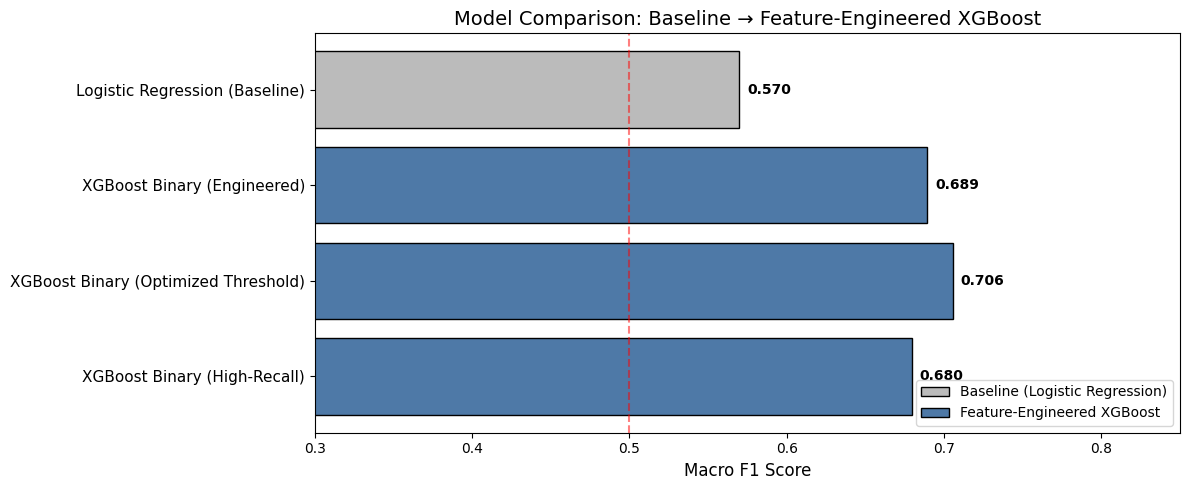

In [23]:
# Visual comparison: Baseline vs Engineered XGBoost
fig, ax = plt.subplots(figsize=(12, 5))

colors = []
for _, row in all_models.iterrows():
    if row['Notebook'] == '3':
        colors.append('#bbb')       # Baseline gray
    else:
        colors.append('#4e79a7')     # Engineered models blue

bars = ax.barh(range(len(all_models)), all_models['Macro_F1'], color=colors, edgecolor='black')

ax.set_yticks(range(len(all_models)))
ax.set_yticklabels(all_models['Model'], fontsize=11)
ax.set_xlabel('Macro F1 Score', fontsize=12)
ax.set_title('Model Comparison: Baseline → Feature-Engineered XGBoost', fontsize=14)
ax.set_xlim(0.3, 0.85)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random Baseline')
ax.invert_yaxis()

# Add value labels
for i, (f1_val, nb) in enumerate(zip(all_models['Macro_F1'], all_models['Notebook'])):
    ax.text(f1_val + 0.005, i, f'{f1_val:.3f}', va='center', fontsize=10, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#bbb', edgecolor='black', label='Baseline (Logistic Regression)'),
    Patch(facecolor='#4e79a7', edgecolor='black', label='Feature-Engineered XGBoost'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusion

The **XGBoost Binary model with the high-recall threshold (0.469)** is the best performing model in this notebook, achieving an **At-Risk Recall of 0.80** on the 2024 holdout set.

We select **Recall** as the primary evaluation metric because this model is designed as a pre-screening tool for California social services - the cost of missing an at-risk family (false negative) far outweighs the cost of flagging a stable household for review (false positive). An At-Risk Recall of 0.80 means 4 out of 5 at-risk households are correctly identified for intervention.

---
## Hyperparameter Tuning with GridSearchCV

GridSearchCV creates a matrix of parameter combinations and evaluates each using cross-validation, returning the best-performing configuration.

In [24]:
from sklearn.model_selection import GridSearchCV

# Use undersampled training data for grid search (balanced classes)
# This is the same data used for final model training
print(f'GridSearchCV training data: {X_train_us_final.shape}')
print(f'Class distribution: {Counter(y_train_us_final)}')

# Define parameter grid — focused on the most impactful hyperparameters
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [300, 500],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)
print(f'\nTotal parameter combinations: {total_combos}')
print(f'With 3-fold CV: {total_combos * 3} model fits')

# GridSearchCV with stratified 3-fold (balancing speed vs thoroughness)
xgb_grid = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

print('\nStarting GridSearchCV...')
grid_search.fit(X_train_us_final, y_train_us_final)

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV Macro F1: {grid_search.best_score_:.4f}')

GridSearchCV training data: (724186, 20)
Class distribution: Counter({0: 362093, 1: 362093})

Total parameter combinations: 162
With 3-fold CV: 486 model fits

Starting GridSearchCV...
Fitting 3 folds for each of 162 candidates, totalling 486 fits

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 500, 'subsample': 0.9}
Best CV Macro F1: 0.7489


In [25]:
# Compare: Original (fixed) params vs GridSearchCV best params
print('=' * 80)
print('HYPERPARAMETER COMPARISON: Before vs After GridSearchCV')
print('=' * 80)

original_params = {
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 500,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
}

best_params = grid_search.best_params_

print(f'\n{"Parameter":<25} {"Original":<15} {"GridSearchCV Best":<15} {"Changed?":<10}')
print('-' * 65)
for param in original_params:
    orig = original_params[param]
    best = best_params.get(param, orig)
    changed = 'YES' if orig != best else 'no'
    print(f'{param:<25} {str(orig):<15} {str(best):<15} {changed:<10}')

# Retrain with best parameters on the full undersampled training set
xgb_tuned = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    early_stopping_rounds=30,
    **best_params
)

xgb_tuned.fit(
    X_train_us_final, y_train_us_final,
    eval_set=[(X_test_final, y_test)],
    verbose=False
)

# Evaluate tuned model on 2024 holdout
y_pred_tuned = xgb_tuned.predict(X_test_final)
y_proba_tuned = xgb_tuned.predict_proba(X_test_final)[:, 1]

tuned_f1 = f1_score(y_test, y_pred_tuned, average='macro')
tuned_acc = (y_pred_tuned == y_test).mean()
tuned_bal_acc = balanced_accuracy_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned, pos_label=1)

print(f'\n=== Tuned XGBoost — 2024 Holdout Results ===')
print(classification_report(y_test, y_pred_tuned, target_names=['Stable', 'At-Risk']))
print(f'Macro F1: {tuned_f1:.4f}')
print(f'Balanced Accuracy: {tuned_bal_acc:.4f}')
print(f'At-Risk Recall: {tuned_recall:.4f}')

# Side-by-side comparison
orig_f1 = f1_score(y_test, y_pred_xgb, average='macro')
orig_recall = recall_score(y_test, y_pred_xgb, pos_label=1)

print(f'\n{"Metric":<25} {"Original":<15} {"Tuned":<15} {"Delta":<15}')
print('-' * 65)
print(f'{"Macro F1":<25} {orig_f1:<15.4f} {tuned_f1:<15.4f} {tuned_f1 - orig_f1:+.4f}')
print(f'{"Accuracy":<25} {(y_pred_xgb == y_test).mean():<15.4f} {tuned_acc:<15.4f} {tuned_acc - (y_pred_xgb == y_test).mean():+.4f}')
print(f'{"At-Risk Recall":<25} {orig_recall:<15.4f} {tuned_recall:<15.4f} {tuned_recall - orig_recall:+.4f}')
print(f'{"Balanced Accuracy":<25} {balanced_accuracy_score(y_test, y_pred_xgb):<15.4f} {tuned_bal_acc:<15.4f} {tuned_bal_acc - balanced_accuracy_score(y_test, y_pred_xgb):+.4f}')

HYPERPARAMETER COMPARISON: Before vs After GridSearchCV

Parameter                 Original        GridSearchCV Best Changed?  
-----------------------------------------------------------------
max_depth                 6               8               YES       
learning_rate             0.1             0.05            YES       
n_estimators              500             500             no        
subsample                 0.8             0.9             YES       
colsample_bytree          0.8             0.7             YES       

=== Tuned XGBoost — 2024 Holdout Results ===
              precision    recall  f1-score   support

      Stable       0.91      0.72      0.80    236581
     At-Risk       0.46      0.78      0.57     71898

    accuracy                           0.73    308479
   macro avg       0.68      0.75      0.69    308479
weighted avg       0.81      0.73      0.75    308479

Macro F1: 0.6894
Balanced Accuracy: 0.7472
At-Risk Recall: 0.7756

Metric               

---
## Leave-One-Out Feature Importance Analysis

This approach complements XGBoost's built-in feature importance (gain-based) by measuring the *actual impact on model performance* when each feature is removed. A large F1 drop when a feature is removed confirms it is truly important; a small drop (or improvement) suggests the feature may be redundant.

In [26]:
# Leave-One-Out Feature Analysis
# For each feature: drop it, retrain XGBoost, measure F1 change vs full model

# Baseline: full model F1 on holdout (using original fixed params for consistency)
baseline_f1_loo = f1_score(y_test, y_pred_xgb, average='macro')
print(f'Baseline Macro F1 (all {len(optimal_features)} features): {baseline_f1_loo:.4f}\n')

loo_results = []

for feature in optimal_features:
    # Drop this single feature
    remaining_features = [f for f in optimal_features if f != feature]
    
    X_train_loo = X_train_us_final[remaining_features]
    X_test_loo = X_test_final[remaining_features]
    
    # Train with same hyperparameters as original model
    model_loo = xgb.XGBClassifier(
        objective='binary:logistic',
        max_depth=6, learning_rate=0.1,
        n_estimators=500, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', early_stopping_rounds=30
    )
    model_loo.fit(X_train_loo, y_train_us_final,
                  eval_set=[(X_test_loo, y_test)], verbose=False)
    
    y_pred_loo = model_loo.predict(X_test_loo)
    loo_f1 = f1_score(y_test, y_pred_loo, average='macro')
    loo_recall = recall_score(y_test, y_pred_loo, pos_label=1)
    f1_delta = loo_f1 - baseline_f1_loo
    
    loo_results.append({
        'Feature_Removed': feature,
        'Macro_F1': loo_f1,
        'F1_Delta': f1_delta,
        'AtRisk_Recall': loo_recall
    })
    
    direction = '▼' if f1_delta < -0.001 else ('▲' if f1_delta > 0.001 else '≈')
    print(f'  Drop {feature:30s} → F1: {loo_f1:.4f} ({f1_delta:+.4f}) {direction}')

loo_df = pd.DataFrame(loo_results).sort_values('F1_Delta', ascending=True)
print(f'\n=== Leave-One-Out Summary ===')
print(f'Most impactful feature (biggest F1 drop when removed):')
most_important = loo_df.iloc[0]
print(f'  {most_important["Feature_Removed"]}: F1 drops by {most_important["F1_Delta"]:+.4f}')
least_important = loo_df.iloc[-1]
print(f'Least impactful feature (smallest F1 change when removed):')
print(f'  {least_important["Feature_Removed"]}: F1 changes by {least_important["F1_Delta"]:+.4f}')

Baseline Macro F1 (all 20 features): 0.6892

  Drop MSP                            → F1: 0.6870 (-0.0021) ▼
  Drop education_tier                 → F1: 0.6835 (-0.0057) ▼
  Drop WKHP                           → F1: 0.6791 (-0.0101) ▼
  Drop ESR                            → F1: 0.6877 (-0.0014) ▼
  Drop ENG                            → F1: 0.6859 (-0.0033) ▼
  Drop CIT                            → F1: 0.6878 (-0.0014) ▼
  Drop MIG                            → F1: 0.6853 (-0.0039) ▼
  Drop has_insurance                  → F1: 0.6882 (-0.0010) ≈
  Drop MAR                            → F1: 0.6895 (+0.0003) ≈
  Drop is_latinx                      → F1: 0.6890 (-0.0002) ≈
  Drop AGEP                           → F1: 0.6773 (-0.0119) ▼
  Drop SEX                            → F1: 0.6871 (-0.0020) ▼
  Drop race_black                     → F1: 0.6895 (+0.0003) ≈
  Drop OCCP                           → F1: 0.6849 (-0.0042) ▼
  Drop race_white                     → F1: 0.6894 (+0.0002) ≈
  Drop rac

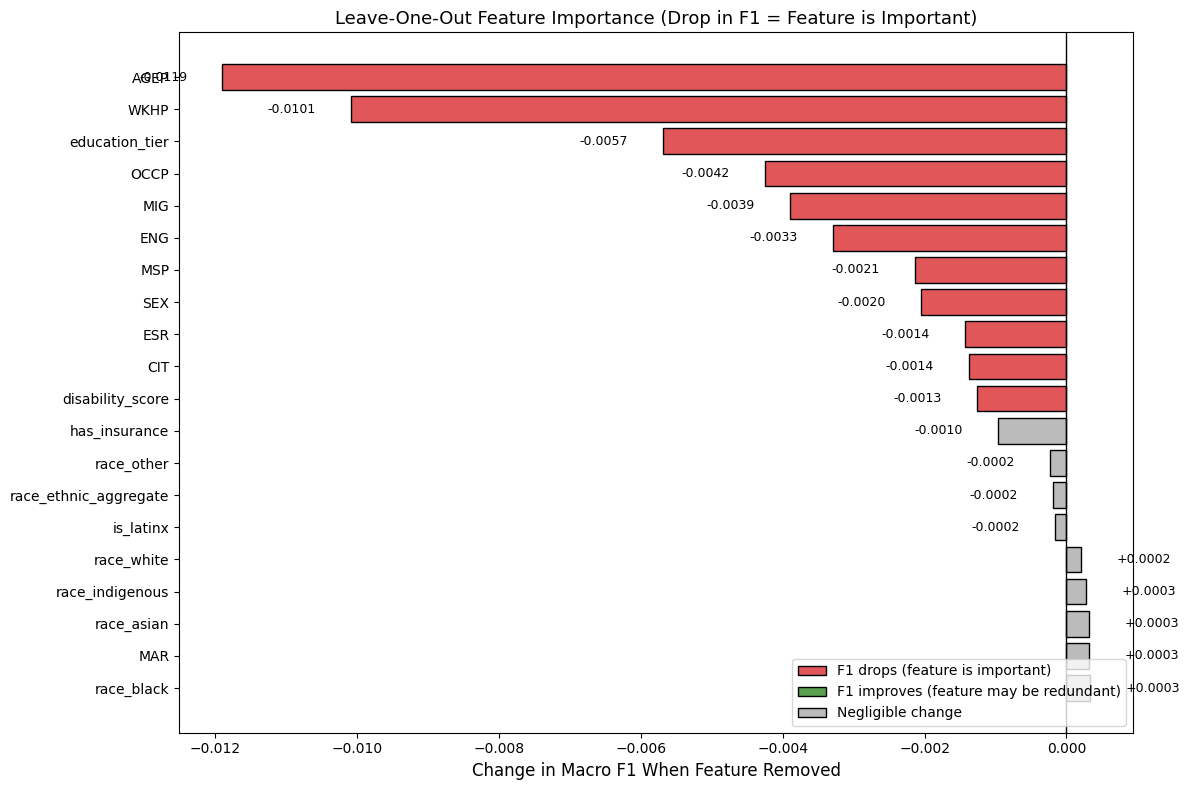


=== Leave-One-Out Feature Ranking (sorted by impact) ===
Rank   Feature                        F1 Without      F1 Delta        Recall    
----------------------------------------------------------------------------
1      AGEP                           0.6773          -0.0119         0.7809    
2      WKHP                           0.6791          -0.0101         0.7568    
3      education_tier                 0.6835          -0.0057         0.7713    
4      OCCP                           0.6849          -0.0042         0.7682    
5      MIG                            0.6853          -0.0039         0.7792    
6      ENG                            0.6859          -0.0033         0.7754    
7      MSP                            0.6870          -0.0021         0.7699    
8      SEX                            0.6871          -0.0020         0.7716    
9      ESR                            0.6877          -0.0014         0.7719    
10     CIT                            0.6878          -

In [27]:
# Visualize Leave-One-Out results
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#e15759' if d < -0.001 else ('#59a14f' if d > 0.001 else '#bbb')
          for d in loo_df['F1_Delta']]

bars = ax.barh(loo_df['Feature_Removed'], loo_df['F1_Delta'], color=colors, edgecolor='black')

ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Change in Macro F1 When Feature Removed', fontsize=12)
ax.set_title('Leave-One-Out Feature Importance (Drop in F1 = Feature is Important)', fontsize=13)
ax.invert_yaxis()

# Add value labels
for i, (feat, delta) in enumerate(zip(loo_df['Feature_Removed'], loo_df['F1_Delta'])):
    ax.text(delta + (0.0005 if delta >= 0 else -0.0005), i,
            f'{delta:+.4f}', va='center', fontsize=9,
            ha='left' if delta >= 0 else 'right')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e15759', edgecolor='black', label='F1 drops (feature is important)'),
    Patch(facecolor='#59a14f', edgecolor='black', label='F1 improves (feature may be redundant)'),
    Patch(facecolor='#bbb', edgecolor='black', label='Negligible change'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/leave_one_out_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranked table
print('\n=== Leave-One-Out Feature Ranking (sorted by impact) ===')
print(f'{"Rank":<6} {"Feature":<30} {"F1 Without":<15} {"F1 Delta":<15} {"Recall":<10}')
print('-' * 76)
for rank, (_, row) in enumerate(loo_df.iterrows(), 1):
    print(f'{rank:<6} {row["Feature_Removed"]:<30} {row["Macro_F1"]:<15.4f} {row["F1_Delta"]:<+15.4f} {row["AtRisk_Recall"]:<10.4f}')

---
## PCA 

In [28]:
from sklearn.decomposition import PCA
import plotly.express as px

# Scale features before PCA (PCA is sensitive to scale unlike XGBoost)
scaler_pca = StandardScaler()
X_test_scaled = scaler_pca.fit_transform(X_test_final)

# Fit PCA with 3 components
pca = PCA(n_components=3, random_state=42)
X_pca_3d = pca.fit_transform(X_test_scaled)

print(f'PCA explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained (3 components): {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.1f}%)')

# Create a dataframe for Plotly
pca_df = pd.DataFrame({
    'PC1': X_pca_3d[:, 0],
    'PC2': X_pca_3d[:, 1],
    'PC3': X_pca_3d[:, 2],
    'Poverty_Status': y_test.map({0: 'Stable', 1: 'At-Risk'}).values
})

# Sample for performance (300k points is too many for interactive plot)
sample_size = 10000
pca_sample = pca_df.sample(n=sample_size, random_state=42)
print(f'\nSampled {sample_size:,} points for 3D visualization')
print(f'Sample class distribution: {pca_sample["Poverty_Status"].value_counts().to_dict()}')

PCA explained variance ratio: [0.17335203 0.14962014 0.11762353]
Total variance explained (3 components): 0.4406 (44.1%)

Sampled 10,000 points for 3D visualization
Sample class distribution: {'Stable': 7714, 'At-Risk': 2286}


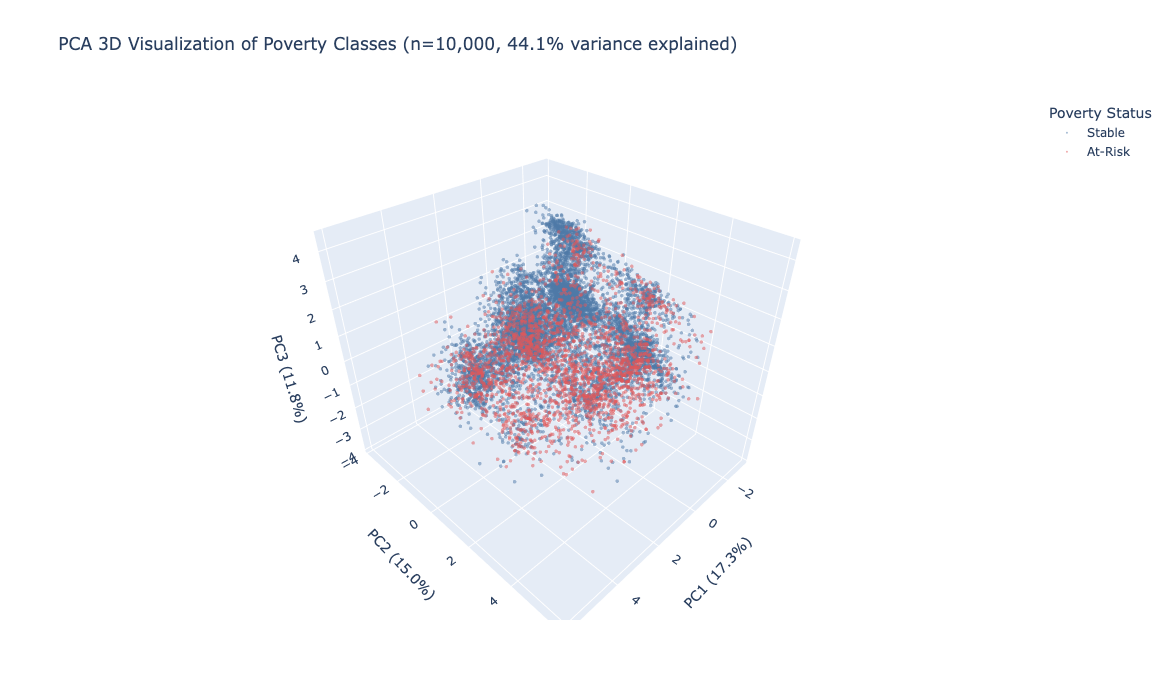

In [29]:
# 3D Interactive Scatter Plot with Plotly
fig_3d = px.scatter_3d(
    pca_sample,
    x='PC1', y='PC2', z='PC3',
    color='Poverty_Status',
    color_discrete_map={'Stable': '#4e79a7', 'At-Risk': '#e15759'},
    opacity=0.5,
    title=f'PCA 3D Visualization of Poverty Classes (n={sample_size:,}, {pca.explained_variance_ratio_.sum()*100:.1f}% variance explained)',
    labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
            'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
            'PC3': f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'},
    width=900,
    height=700
)

fig_3d.update_traces(marker=dict(size=2))
fig_3d.update_layout(
    legend_title_text='Poverty Status',
    scene=dict(
        xaxis_title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'
    )
)
fig_3d.show()

In [30]:
# Also create a 4-class PCA visualization to see poverty severity clusters
y_test_multi_labels = df_test['poverty_risk_score'].astype(int)
severity_map = {0: 'Stable', 1: 'Near Poverty', 2: 'Poverty', 3: 'Deep Poverty'}

pca_df_multi = pd.DataFrame({
    'PC1': X_pca_3d[:, 0],
    'PC2': X_pca_3d[:, 1],
    'PC3': X_pca_3d[:, 2],
    'Poverty_Level': y_test_multi_labels.map(severity_map).values
})

pca_sample_multi = pca_df_multi.sample(n=sample_size, random_state=42)

fig_3d_multi = px.scatter_3d(
    pca_sample_multi,
    x='PC1', y='PC2', z='PC3',
    color='Poverty_Level',
    color_discrete_map={
        'Stable': '#4e79a7',
        'Near Poverty': '#f28e2b',
        'Poverty': '#e15759',
        'Deep Poverty': '#9c1c1c'
    },
    category_orders={'Poverty_Level': ['Stable', 'Near Poverty', 'Poverty', 'Deep Poverty']},
    opacity=0.5,
    title=f'PCA 3D — 4 Poverty Severity Levels (n={sample_size:,})',
    labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
            'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
            'PC3': f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'},
    width=900,
    height=700
)

fig_3d_multi.update_traces(marker=dict(size=2))
fig_3d_multi.update_layout(legend_title_text='Poverty Level')
fig_3d_multi.show()

# PCA component loadings — which features contribute to each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=optimal_features
)

print('\n=== Top Feature Loadings per Principal Component ===')
for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f'\n{pc} (explains {pca.explained_variance_ratio_[int(pc[-1])-1]*100:.1f}% variance):')
    for feat, val in top.items():
        sign = '+' if loadings.loc[feat, pc] > 0 else '-'
        print(f'  {sign}{feat}: {val:.3f}')


=== Top Feature Loadings per Principal Component ===

PC1 (explains 17.3% variance):
  +is_latinx: 0.478
  +race_other: 0.455
  +race_ethnic_aggregate: 0.446
  +ENG: 0.264
  -education_tier: 0.260

PC2 (explains 15.0% variance):
  +ESR: 0.453
  -WKHP: 0.434
  +OCCP: 0.405
  +AGEP: 0.366
  +disability_score: 0.252

PC3 (explains 11.8% variance):
  +CIT: 0.435
  -MSP: 0.379
  -MAR: 0.374
  +race_asian: 0.362
  +ENG: 0.348
